# 1. Libraries and Additional Functions

In [ ]:
#Importing libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import re,os,pickle,gc,time,itertools,copy
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu,SmoothingFunction
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50,ResNet50_Weights
from tqdm import tqdm

In [ ]:
def save_PKL(curr_DICT,path):
    #Make sure the directory exists before saving
    os.makedirs(os.path.dirname(path),exist_ok=True)
    #Write the dictionary to the file using pickle
    with open(path,'wb') as file:
        pickle.dump(curr_DICT,file)
    return curr_DICT

def load_PKL(path):
    #Load a dictionary from a .pkl file
    if os.path.exists(path):
        with open(path,'rb') as file:
            curr_DICT = pickle.load(file)
    #Return an empty dictionary if the file doesn't exist
    else:
        curr_DICT = {}
    return curr_DICT

def setup_device():
    #Choose the right device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    return device

# 2. Original Experiment Using LSTMs

### 2.1 Variable Initializations

In [ ]:
#Define different parts of the path structure
base_path_ext = "data/"
current_application_ext = "image_text_generation/"
data_type_ext = "output_data/"
model_type_ext = "lstm/"
experiment_type_ext = "original/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

#Declare global paths for input and output components
global input_filepath_ext
global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

#Set a path for input data
input_data_type_ext = "input_data/"
input_filepath_ext = base_path_ext + current_application_ext + input_data_type_ext

#Set paths for metrics, models, and plots
metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

#Set a random seed
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

#Set up the device
global device
device = setup_device()

In [ ]:
#Set unregularized parameters
params_unregularized = {
    "model_name": "img_cap_gen_model_LSTM_unregularized",
    "save_interval": 10,
    "batch_size": 128,
    "seq_length": 32,
    "num_layers": 1,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.0,
    "init_weight": 0.1,
    "lr": 0.01,
    "vocab_DICT_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

In [ ]:
#Set regularized parameters
params_regularized = {
    "model_name": "img_cap_gen_model_LSTM_regularized",
    "save_interval": 10,
    "batch_size": 128,
    "seq_length": 32,
    "num_layers": 1,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.5,
    "init_weight": 0.1,
    "lr": 0.01,
    "vocab_DICT_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

### 2.2 Extract and Transform Data

In [ ]:
def preprocess_data(text):
    #Lowercase text
    text = text.lower()
    #Add spacing around punctuation
    text = re.sub(r"([.,!?;])",r" \1 ",text)
    #Remove unwanted characters
    text = re.sub(r"[^a-zA-Z0-9.,!?;]+",r" ",text)
    #Strip and split into tokens
    preprocessed_text = text.strip().split()
    return preprocessed_text

def build_vocab(texts,vocab_DICT_size):
    #Get the most common words from the text data
    word_freq = Counter(itertools.chain.from_iterable(texts))
    most_common_words = word_freq.most_common(vocab_DICT_size - 4)

    #Initialize a vocabulary dictionary with special tokens
    vocab_DICT = {
        '<pad>': 0,
        '<unk>': 1,
        '<sos>': 2,
        '<eos>': 3,
    }

    #Fill the vocabulary dictionary
    ind = 4
    for word,_ in most_common_words:
        vocab_DICT[word] = ind
        ind += 1
    return vocab_DICT
 
def get_datasets(params,train_ratio=0.7,valid_ratio=0.15,random_state=1234,save_images=False):
    #Load the dataset
    dataset = load_dataset("tsystems/flickr8k")
    
    all_examples_LIST = []
    all_texts = []
    
    #Create directory if it does not exist
    if save_images:
        os.makedirs(input_filepath_ext,exist_ok=True)

    #Process each image-caption pair
    for example in dataset["train"]:
        texts = example['texts']
        tokenized_texts = [preprocess_data(text) for text in texts]
        all_texts.extend(tokenized_texts)

        #Create a new entry for each caption
        for tokens in tokenized_texts:
            all_examples_LIST.append({
                "image_filename": example['image_filename'],
                "text_tokens": tokens
            })
        
        #Save image locally   
        if save_images:
            image_path = os.path.join(input_filepath_ext,example['image_filename'])
            image = example['image']
            image.save(image_path)

    #Build the vocabulary from all tokenized text
    vocab_DICT = build_vocab(all_texts,params["vocab_DICT_size"])

    #Split data into train valid test
    train_data,valid_and_test_data = train_test_split(all_examples_LIST,train_size=train_ratio,random_state=random_state)
    valid_size = valid_ratio/(1 - train_ratio)
    valid_data,test_data = train_test_split(valid_and_test_data,test_size=1-valid_size,random_state=random_state)
    return train_data,valid_data,test_data,vocab_DICT

In [ ]:
#Get train valid test unregularized data and vocabulary
save_images = False #Change to True to save images
data_train_unregularized,data_valid_unregularized,data_test_unregularized,vocab_DICT_map_unregularized = get_datasets(params_unregularized,save_images=save_images)

In [ ]:
#Get train valid test regularized data and vocabulary
data_train_regularized = copy.deepcopy(data_train_unregularized)
data_valid_regularized = copy.deepcopy(data_valid_unregularized)
data_test_regularized = copy.deepcopy(data_test_unregularized)
vocab_DICT_map_regularized = copy.deepcopy(vocab_DICT_map_unregularized)

### 2.3 Create Flickr8K Dataset Class

In [ ]:
class Flickr8kDataset(torch.utils.data.Dataset):
    def __init__(self, data, vocab_DICT,image_folder,seq_length, transform=None):
        #Set class parameters
        self.data = data
        self.vocab_DICT = vocab_DICT
        self.image_folder = image_folder
        self.seq_length = seq_length
        
        #Define default transform if none is provided
        self.transform = transform if transform else transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]
            )
        ])
        
    def __len__(self):
        #Get the total number of image-caption pairs
        data_len = len(self.data)
        return data_len

    def __getitem__(self, ind):
        #Load and return image tensor and corresponding text tensor
        item = self.data[ind]
        image_path = os.path.join(input_filepath_ext,item["image_filename"])
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        text_tensor = self.numericalize_tokens(item["text_tokens"])
        return image_tensor,text_tensor
    
    def numericalize_tokens(self, tokens):
        #Convert tokenized caption into indexed tensor, with padding
        tokens = tokens[:self.seq_length - 2]
        indices = [self.vocab_DICT.get(word, self.vocab_DICT["<unk>"]) for word in tokens]
        indices = [self.vocab_DICT["<sos>"]] + indices + [self.vocab_DICT["<eos>"]]
        pad_len = self.seq_length - len(indices)
        indices += [self.vocab_DICT["<pad>"]]*pad_len
        indices_torch = torch.tensor(indices)
        return indices_torch

def collate_fn(batch):
    #Batch image and text tensors
    images,texts = zip(*batch)
    images = torch.stack(images)
    texts = torch.stack(texts)
    return images,texts

In [ ]:
#Create unregularized train valid and test datasets
train_dataset_unregularized = Flickr8kDataset(data_train_unregularized,vocab_DICT_map_unregularized,input_filepath_ext,params_unregularized["seq_length"])
valid_dataset_unregularized = Flickr8kDataset(data_valid_unregularized,vocab_DICT_map_unregularized,input_filepath_ext,params_unregularized["seq_length"])
test_dataset_unregularized = Flickr8kDataset(data_test_unregularized,vocab_DICT_map_unregularized,input_filepath_ext,params_unregularized["seq_length"])

#Wrap unregularized datasets in DataLoader objects
train_loader_unregularized = DataLoader(train_dataset_unregularized,batch_size=params_unregularized["batch_size"],shuffle=True,collate_fn=collate_fn)
valid_loader_unregularized = DataLoader(valid_dataset_unregularized,batch_size=params_unregularized["batch_size"],shuffle=False,collate_fn=collate_fn)
test_loader_unregularized = DataLoader(test_dataset_unregularized,batch_size=params_unregularized["batch_size"],shuffle=False,collate_fn=collate_fn)

In [ ]:
#Create regularized train valid and test datasets
train_dataset_regularized = Flickr8kDataset(data_train_regularized,vocab_DICT_map_regularized,input_filepath_ext,params_regularized["seq_length"])
valid_dataset_regularized = Flickr8kDataset(data_valid_regularized,vocab_DICT_map_regularized,input_filepath_ext,params_regularized["seq_length"])
test_dataset_regularized = Flickr8kDataset(data_test_regularized,vocab_DICT_map_regularized,input_filepath_ext,params_regularized["seq_length"])

#Wrap regularized datasets in DataLoader objects
train_loader_regularized = DataLoader(train_dataset_regularized,batch_size=params_regularized["batch_size"],shuffle=True,collate_fn=collate_fn)
valid_loader_regularized = DataLoader(valid_dataset_regularized,batch_size=params_regularized["batch_size"],shuffle=False,collate_fn=collate_fn)
test_loader_regularized = DataLoader(test_dataset_regularized,batch_size=params_regularized["batch_size"],shuffle=False,collate_fn=collate_fn)

### 2.4. LSTM Cell Class 

In [ ]:
class LSTMCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super(LSTMCell,self).__init__()
        #Apply linear transformation for input and hidden state
        self.W = nn.Linear(input_size,4*hidden_size)
        self.U = nn.Linear(hidden_size,4*hidden_size)
    
    def forward(self,x,prev_c,prev_h):
        #Compute combined linear transformations for all gates
        gates = self.W(x) + self.U(prev_h)
        #Split the result into all gates
        i,f,o,g = gates.chunk(4,dim=-1)
        
        #Apply activation functions to respective gates
        i,f,o = torch.sigmoid(i),torch.sigmoid(f),torch.sigmoid(o)
        g = torch.tanh(g)
        
        #Update cell state
        next_c = f*prev_c + i*g
        #Compute next hidden state
        next_h = o*torch.tanh(next_c)
        return next_c,next_h

### 2.5 LSTM Encoder Class

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self,params):
        super(ImageEncoder,self).__init__()
        encoded_size = params["layer_size"]
        #Load a pretrained ResNet-50 model
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        
        #Use all layers except the final classification layer
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])    
        
        #Freeze ResNet weights
        for param in self.cnn.parameters():
            param.requires_grad = False
        
        #Add a fully connected layer
        self.fc = nn.Linear(resnet.fc.in_features, encoded_size)
        #Add batch normalization to stabilize training
        self.bn = nn.BatchNorm1d(encoded_size,momentum=0.01)
        #Initialize weights for the new layers
        self.init_weights(params)
    
    def init_weights(self,params):
        #Initialize all parameters uniformly
        for param in self.fc.parameters():
            if param.dim() > 1:
                param.data.uniform_(-params["init_weight"],params["init_weight"]) 
            else:
                nn.init.zeros_(param)
        
        #Initialize batch norm weights and biases
        nn.init.uniform_(self.bn.weight,-params["init_weight"],params["init_weight"])
        nn.init.zeros_(self.bn.bias)
    
    def forward(self,images):
        #Pass the image through ResNet to get features
        features = self.cnn(images)
        features = features.view(features.size(0),-1)
        #Project and normalize features
        features = self.fc(features)
        features = self.bn(features)
        return features

### 2.6. LSTM Decoder Class

In [ ]:
class LSTMDecoder(nn.Module):
    def __init__(self,params):
        super(LSTMDecoder,self).__init__()
        self.vocab_DICT_size = params["vocab_DICT_size"]
        self.layer_size = params["layer_size"]
        self.embedding = nn.Embedding(self.vocab_DICT_size,self.layer_size)
        
        self.lstm_cells = nn.ModuleList([LSTMCell(self.layer_size,self.layer_size) for _ in range(params["num_layers"])])
        
        self.init_h = nn.Linear(self.layer_size,self.layer_size)
        self.init_c = nn.Linear(self.layer_size,self.layer_size)
        
        self.dropout = nn.Dropout(params["dropout"])
        self.fc = nn.Linear(self.layer_size,self.vocab_DICT_size)
        self.init_weights(params)

    def init_weights(self,params):
        #Initialize all parameters uniformly
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"],params["init_weight"])
        
        for name,param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)
                if 'forget' in name:
                    n = param.size(0)
                    param.data[n//4:n//2].fill_(1) 

    #Initialize hidden layers
    def init_hidden(self,image_features):
        h = [self.init_h(image_features) for _ in range(len(self.lstm_cells))]
        c = [self.init_c(image_features) for _ in range(len(self.lstm_cells))]
        hidden = (c,h)
        return hidden

    #Propagate input through the model
    def forward(self, input_token, hidden):
        embedded = self.embedding(input_token)
        x = embedded
        c, h = hidden

        c, h = hidden
        for i, cell in enumerate(self.lstm_cells):
            prev_c = c[i]
            prev_h = h[i]
            prev_c, prev_h = cell(x, prev_c, prev_h)
            x = self.dropout(prev_h)
            c[i], h[i] = prev_c, prev_h

        output = self.fc(x)
        hidden = (c,h)
        return output,hidden

### 2.7 Save and Load Models

In [ ]:
#Save model and metrics
def save_model_and_metrics(model,params,epoch_num,metrics_DICT,best_model=False,last_epoch=False):
    if last_epoch:
        model_path = f"{models_filepath_ext}{params['model_name']}_last_epoch.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"
    else:    
        model_path = f"{models_filepath_ext}{params['model_name']}_best.pth" if best_model else f"{models_filepath_ext}{params['model_name']}_epoch_{epoch_num + 1}.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_metrics_best.pkl" if best_model else f"{metrics_filepath_ext}{params['model_name']}_metrics_epoch_{epoch_num + 1}.pkl"
    
    metrics_DICT.update(params)
    metrics_DICT["model_path"] = model_path
    metrics_DICT["metrics_path"] = metrics_path
    
    os.makedirs(os.path.dirname(model_path),exist_ok=True)           
    torch.save({
        'encoder_state_dict': model['encoder'].state_dict(),
        'decoder_state_dict': model['decoder'].state_dict()
    }, model_path)
    save_PKL(metrics_DICT,metrics_path)
    return metrics_DICT

#Initialize or load model
def check_and_load_model(params,epoch_num=0,best_model=False,load_model=True,last_epoch=False,model_class="LSTMModel"):
    if last_epoch:
        model_path = f"{models_filepath_ext}{params['model_name']}_last_epoch.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"
    else:
        model_path = f"{models_filepath_ext}{params['model_name']}_best.pth" if best_model else f"{models_filepath_ext}{params['model_name']}_epoch_{epoch_num + 1}.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_metrics_best.pkl" if best_model else f"{metrics_filepath_ext}{params['model_name']}_metrics_epoch_{epoch_num + 1}.pkl"

    if model_class == "LSTMModel":
        encoder = ImageEncoder(params)
        decoder = LSTMDecoder(params)
    else:
        encoder = ImageEncoder(params)
        decoder = GRUDecoder(params)
    
    if os.path.exists(model_path) and load_model:
        checkpoint = torch.load(model_path)
        encoder.load_state_dict(checkpoint['encoder_state_dict'])
        decoder.load_state_dict(checkpoint['decoder_state_dict'])
        metrics_DICT = load_PKL(metrics_path)
    else:
        metrics_DICT = {"epoch_list": [],"train_ppl": [],"valid_ppl": [],"valid_bleu": [],"test_ppl": 0,"test_bleu": 0,"best_valid_ppl": np.inf,"best_valid_bleu": -np.inf,"best_epoch": 0}

    device = setup_device()
    encoder.to(device)
    decoder.to(device)
    model = {"encoder": encoder, "decoder": decoder}
    return model,model_path,metrics_DICT

In [ ]:
#Initialize or load unregularized model
last_epoch_unregularized = False #Change this to False to train from scratch
epoch_num_unregularized = 0 #Change this to load at a specific epoch
criterion = torch.nn.CrossEntropyLoss() 

model_unregularized,model_path_unregularized,metrics_unregularized_DICT = check_and_load_model(params_unregularized, epoch_num_unregularized, last_epoch=last_epoch_unregularized)
encoder_unregularized = model_unregularized['encoder']
decoder_unregularized = model_unregularized['decoder']
optimizer_unregularized = optim.Adam(list(encoder_unregularized.parameters()) + list(decoder_unregularized.parameters()), lr=params_unregularized["lr"])

In [ ]:
#Initialize or load regularized model
last_epoch_regularized = False #Change this to False to train from scratch
epoch_num_regularized = 0 #Change this to load at a specific epoch

model_regularized,model_path_regularized,metrics_regularized_DICT = check_and_load_model(params_regularized,epoch_num_regularized,last_epoch=last_epoch_regularized)
encoder_regularized = model_regularized['encoder']
decoder_regularized = model_regularized['decoder']
optimizer_regularized = optim.Adam(list(encoder_regularized.parameters()) + list(decoder_regularized.parameters()), lr=params_regularized["lr"])

### 2.8 Compute BLEU Score

In [ ]:
#Decodes a sequence using a greedy algorithm
def greedy_decode(src,encoder,decoder,params,device,max_len=50,start_token=1,end_token=2,model_class="LSTMModel"):
    encoder.eval()
    decoder.eval()

    if src.dim() == 1:
        src = src.unsqueeze(0)
    elif src.size(0) > 1:
        raise ValueError("greedy_decode expects a single example, but got a batch.")

    src = src.to(device)
    encoder_outputs = encoder(src)
    batch_size = src.size(0)
    
    if model_class == "LSTMModel":
        num_layers = len(decoder.lstm_cells)
    else:
        num_layers = len(num_layers.gru_cells)

    hidden = encoder_outputs

    decoder_input = torch.tensor([[start_token]], device=device)
    decoded_tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden = decoder(decoder_input.squeeze(1), hidden)
            probs = F.log_softmax(output, dim=-1)
            topv, topi = probs.topk(1, dim=-1)
            next_token = topi.squeeze().item()

            if next_token == end_token:
                break

            decoded_tokens.append(next_token)
            decoder_input = topi

    return decoded_tokens

# Performs beam search decoding to generate sequences using the beam search algorithm with a specified beam width
def beam_search_decode(decoder, encoder_output, hidden, params, device):
    beam_width = params.get("beam_width", 5)
    max_len = params.get("seq_length", 50)
    sos_token = params.get("sos_token", 1)
    eos_token = params.get("eos_token", 2)

    beam = [([sos_token], hidden, 0)]

    for _ in range(max_len):
        new_beam = []
        for seq, h, log_prob in beam:
            if seq[-1] == eos_token:
                new_beam.append((seq, h, log_prob))
                continue
            
            decoder_input = torch.tensor([seq[-1]], device=device).unsqueeze(0)  # (1, 1)

            output, new_hidden = decoder(decoder_input, h)
            output = output.squeeze(1) if output.dim() == 3 else output

            probs = F.log_softmax(output, dim=-1)

            topk_probs, topk_indices = torch.topk(probs, beam_width)

            for i in range(beam_width):
                token = topk_indices[0][i].item()
                token_log_prob = topk_probs[0][i].item()
                new_seq = seq + [token]
                new_beam.append((new_seq, new_hidden, log_prob + token_log_prob))

        beam = sorted(new_beam, key=lambda tup: tup[2], reverse=True)[:beam_width]

        if all(seq[-1] == eos_token for seq,_,_ in beam):
            break

    best_seq = beam[0][0]
    cleaned_seq = [token for token in best_seq if token != eos_token]
    cleaned_stripped_seq = cleaned_seq[1:] if cleaned_seq[0] == sos_token else cleaned_seq
    return cleaned_stripped_seq

#Translates a given source sentence using either beam search or greedy decoding
def translate_sentence(src, encoder, decoder, params, device, use_beam_search=False,model_class="LSTMModel"):
    encoder.eval()
    decoder.eval()

    if src.dim() == 1:
        src = src.unsqueeze(0)
    elif src.size(0) > 1:
        raise ValueError("translate_sentence expects a single example, but got a batch.")

    src = src.to(device)
    encoder_outputs = encoder(src)
    batch_size = src.size(0)
    
    if model_class == "LSTMModel":
        num_layers = len(decoder.lstm_cells)
    else:
        num_layers = len(decoder.gru_cells)

    if model_class=="LSTMModel":
        c = [decoder.init_c(encoder_outputs) for _ in range(num_layers)]
        h = [decoder.init_h(encoder_outputs) for _ in range(num_layers)]
        hidden = (c,h)
    else:
        h = [decoder.init_h(encoder_outputs) for _ in range(num_layers)]
        hidden = h

    if use_beam_search:
        best_seq = beam_search_decode(decoder, encoder_outputs, hidden, params, device)
    else:
        best_seq = greedy_decode(src, encoder, decoder, params, device)
    return best_seq

#Translates a batch of sentences and computes the BLEU score for the translations
def translate_and_compute_bleu(batched_data, encoder, decoder, params, tgt_vocab_DICT_map, device, use_beam_search=False,model_class="LSTMModel"):
    references = []
    translations = []

    inv_vocab_DICT_map = {v: k for k, v in tgt_vocab_DICT_map.items()}

    pad_token = tgt_vocab_DICT_map.get('<pad>',0)
    sos_token = tgt_vocab_DICT_map.get('<sos>',2)
    eos_token = tgt_vocab_DICT_map.get('<eos>',3)

    for src_batch, tgt_batch in batched_data:
        batch_size = src_batch.size(0)
        for i in range(batch_size):
            src = src_batch[i]
            tgt = tgt_batch[i]

            output = translate_sentence(src, encoder, decoder, params, device, use_beam_search,model_class=model_class)
            tgt_tokens = tgt.tolist()

            clean_tgt = [token for token in tgt_tokens if token != pad_token and token != sos_token]
            clean_output = [token for token in output if token != pad_token and token != sos_token]

            ref_words = [inv_vocab_DICT_map.get(t, "<unk>").lower() for t in clean_tgt]
            hyp_words = [inv_vocab_DICT_map.get(t, "<unk>").lower() for t in clean_output]

            references.append([ref_words])
            translations.append(hyp_words)

    smoothie = SmoothingFunction().method4
    bleu_score = corpus_bleu(references, translations, smoothing_function=smoothie)
    return bleu_score

### 2.9. Train and Evaluate Model

In [ ]:
#Forward pass for training or evaluation
def fp(batch, encoder, decoder, params, criterion, train_mode=False,model_class="LSTMModel"):
    if train_mode:
        encoder.train()
        decoder.train()
    else:
        encoder.eval()
        decoder.eval()

    src,tgt = batch
    
    device = setup_device()
    src,tgt = src.to(device), tgt.to(device)

    encoder_outputs = encoder(src)

    batch_size = src.size(0)
    if model_class == "LSTMModel":
        num_layers = len(decoder.lstm_cells)
    else:
        num_layers = len(decoder.gru_cells)
    device = src.device

    if model_class=="LSTMModel":
        c = [decoder.init_c(encoder_outputs) for _ in range(num_layers)]
        h = [decoder.init_h(encoder_outputs) for _ in range(num_layers)]
        hidden = (c,h)
    else:
        h = [decoder.init_h(encoder_outputs) for _ in range(num_layers)]
        hidden = h

    decoder_input = tgt[:, 0]
    losses = []

    context_manager = torch.enable_grad() if train_mode else torch.no_grad()
    with context_manager:
        for t in range(1, tgt.size(1)):
            output, hidden = decoder(decoder_input, hidden)
            loss_t = criterion(output, tgt[:, t])
            losses.append(loss_t)
            decoder_input = tgt[:, t]

    loss = torch.stack(losses).mean()
    return loss

#Backpropagation for training
def bp(loss, encoder, decoder, params, optimizer):
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), params["max_grad_norm"])
    optimizer.step()
    gc.collect()
    return

#Runs a single epoch of training or evaluation
def run_epoch(batched_data, encoder, decoder, params, optimizer, criterion, train_mode=False,model_class="LSTMModel"):
    total_loss = 0
    for batch in batched_data:
        loss = fp(batch, encoder, decoder, params, criterion, train_mode=train_mode,model_class=model_class)
        bp(loss, encoder, decoder, params, optimizer)
        total_loss += loss.item()
    ppl = torch.exp(torch.tensor(total_loss/len(batched_data)))
    return ppl

#Training loop
def train(batched_train, batched_valid, model,metrics_DICT, params, optimizer, criterion, tgt_vocab_DICT_map, patience=3, last_epoch=False,valid_metric="PPL",model_class="LSTMModel"):
    encoder = model['encoder']
    decoder = model['decoder']
    temp_metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"
    if not last_epoch or not os.path.exists(temp_metrics_path):
        epoch_list = metrics_DICT.get("epoch_list", [])
        train_ppl_list = metrics_DICT.get("train_ppl", [])
        valid_ppl_list = metrics_DICT.get("valid_ppl", [])
        valid_bleu_list = metrics_DICT.get("valid_bleu", [])
        best_valid_ppl = metrics_DICT.get("best_valid_ppl", np.inf)
        best_valid_bleu = metrics_DICT.get("best_valid_bleu", -np.inf)
        best_epoch = metrics_DICT.get("best_epoch", 0)

        curr_epoch = len(epoch_list)
        max_num_epochs = params["max_max_epoch"]
        for epoch in tqdm(range(curr_epoch, max_num_epochs)):
            train_ppl = run_epoch(batched_train, encoder, decoder, params, optimizer, criterion, train_mode=True,model_class=model_class)
            valid_ppl, valid_bleu,_ = evaluate(batched_valid, encoder, decoder, metrics_DICT, params, criterion, tgt_vocab_DICT_map, eval_state=False,model_class=model_class)

            print(f'Epoch {epoch + 1}/{max_num_epochs}, Train PPL: {train_ppl:.4f}, Val PPL: {valid_ppl:.4f}')
            #print(f'Epoch {epoch + 1}/{max_num_epochs}, Train PPL: {train_ppl:.4f}, Val PPL: {valid_ppl:.4f}, Val BLEU: {valid_bleu:.4f}')
            epoch_list.append(epoch + 1)
            train_ppl_list.append(train_ppl)
            valid_ppl_list.append(valid_ppl)
            valid_bleu_list.append(valid_bleu)

            if epoch > params["max_epoch"]:
                for param_group in optimizer.param_groups:
                    param_group['lr'] /= params["decay"]

            if (epoch + 1) % params["save_interval"] == 0 or epoch == max_num_epochs - 1:
                metrics_DICT.update({
                    "epoch_list": epoch_list.copy(),
                    "train_ppl": train_ppl_list.copy(),
                    "valid_ppl": valid_ppl_list.copy(),
                    "valid_bleu": valid_bleu_list.copy()
                })
                metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT)

            if valid_metric == "PPL":
                if valid_ppl < best_valid_ppl:
                    best_valid_ppl = valid_ppl
                    best_epoch = epoch + 1
                    metrics_DICT.update({
                        "best_valid_ppl": valid_ppl,
                        "best_valid_bleu": best_valid_bleu,
                        "best_epoch": epoch + 1,
                    })
                    metrics_DICT = save_model_and_metrics(model,params,epoch,metrics_DICT,best_model=True)
            else:
                if valid_bleu > best_valid_bleu:
                    best_valid_bleu = valid_bleu
                    best_epoch = epoch + 1
                    metrics_DICT.update({
                        "best_valid_ppl": valid_ppl,
                        "best_valid_bleu": best_valid_bleu,
                        "best_epoch": epoch + 1,
                    })
                    metrics_DICT = save_model_and_metrics(model,params,epoch,metrics_DICT,best_model=True)

            if patience is not None and patience > 0 and (epoch + 1 - best_epoch) >= patience:
                metrics_DICT = save_model_and_metrics(model,params,epoch,metrics_DICT,best_model=False,last_epoch=True)
                print(f"Early stopping at epoch {epoch + 1} (no improvement for {patience} epochs).")
                break
            
            if epoch == max_num_epochs - 1:
                metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT, best_model=False, last_epoch=True)
    return model,metrics_DICT

#Evaluation loop
def evaluate(batched_data, encoder, decoder, metrics_DICT, params, criterion, tgt_vocab_DICT_map, eval_state=True, best_model=False, last_epoch=False,model_class="LSTMModel"):
    encoder.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in batched_data:
            loss = fp(batch, encoder, decoder, params, criterion,model_class=model_class)
            total_loss += loss.item()

    eval_ppl = torch.exp(torch.tensor(total_loss/len(batched_data)))
    if eval_state:
        #eval_bleu = translate_and_compute_bleu(batched_data, encoder, decoder, params, tgt_vocab_DICT_map, beam_search=params["beam_search"])
        eval_bleu = 0
        #print(f"Test PPL: {eval_ppl:.4f}, BLEU: {eval_bleu:.4f}")
        print(f"Test PPL: {eval_ppl:.4f}")
        metrics_DICT["test_ppl"] = eval_ppl.item()
        metrics_DICT["test_bleu"] = eval_bleu
        epoch = metrics_DICT.get("best_epoch", len(metrics_DICT["epoch_list"]))
        metrics_DICT = save_model_and_metrics({"encoder": encoder, "decoder": decoder}, params, epoch, metrics_DICT, best_model)
    else:
        eval_bleu = 0
        #eval_bleu = translate_and_compute_bleu(batched_data, encoder, decoder, params, tgt_vocab_DICT_map, beam_search=False)

    return eval_ppl,eval_bleu,metrics_DICT

In [ ]:
# Training loop
patience_unregularized = False #Set to 0, None, or False to disable early stopping
model_unregularized,metrics_DICT = train(train_loader_unregularized,valid_loader_unregularized,model_unregularized,metrics_unregularized_DICT,params_unregularized,optimizer_unregularized,criterion,vocab_DICT_map_unregularized)

model_unregularized,_,metrics_unregularized_DICT = check_and_load_model(params_unregularized,metrics_DICT["best_epoch"],best_model=True)
test_ppl,test_bleu,metrics_unregularized_DICT = evaluate(test_loader_unregularized,model_unregularized['encoder'],model_unregularized['decoder'],metrics_unregularized_DICT,params_unregularized,criterion,vocab_DICT_map_unregularized)

  8%|▊         | 1/13 [08:32<1:42:26, 512.20s/it]

Epoch 1/13, Train PPL: 26.4222, Val PPL: 7.9679


 15%|█▌        | 2/13 [17:03<1:33:50, 511.85s/it]

Epoch 2/13, Train PPL: 6.3777, Val PPL: 5.8106


 23%|██▎       | 3/13 [25:20<1:24:10, 505.07s/it]

...

Epoch 11/13, Train PPL: 1.9257, Val PPL: 4.8948


 92%|█████████▏| 12/13 [1:40:13<08:18, 498.44s/it]

Epoch 12/13, Train PPL: 1.8773, Val PPL: 4.9138
Epoch 13/13, Train PPL: 1.8569, Val PPL: 4.9125


100%|██████████| 13/13 [1:48:22<00:00, 500.21s/it]


Test PPL: 4.5963


In [ ]:
patience_regularized = False #Set to 0, None, or False to disable early stopping
model_regularized,metrics_DICT = train(train_loader_regularized,valid_loader_regularized,model_regularized,metrics_regularized_DICT,params_regularized,optimizer_regularized,criterion,vocab_DICT_map_regularized)

model_regularized,_,metrics_regularized_DICT = check_and_load_model(params_regularized,metrics_DICT["best_epoch"],best_model=True)
test_ppl,test_bleu,metrics_regularized_DICT = evaluate(test_loader_regularized,model_regularized['encoder'],model_regularized['decoder'],metrics_regularized_DICT,params_regularized,criterion,vocab_DICT_map_regularized)

  8%|▊         | 1/13 [08:14<1:38:52, 494.35s/it]

Epoch 1/13, Train PPL: 35.8070, Val PPL: 8.9896


 15%|█▌        | 2/13 [16:26<1:30:23, 493.05s/it]

Epoch 2/13, Train PPL: 7.6163, Val PPL: 6.2040


 23%|██▎       | 3/13 [24:41<1:22:17, 493.78s/it]

...

Epoch 11/13, Train PPL: 2.8131, Val PPL: 4.6273


 92%|█████████▏| 12/13 [1:38:50<08:15, 495.99s/it]

Epoch 12/13, Train PPL: 2.7544, Val PPL: 4.6395
Epoch 13/13, Train PPL: 2.7237, Val PPL: 4.6391


100%|██████████| 13/13 [1:47:06<00:00, 494.37s/it]


Test PPL: 4.5133


### 2.10. Plotting Results

In [24]:
#Visualize the train and validation loss
def plot_train_valid(metrics_DICT,save_plot=True,show_plot=True,is_hyperparameter_tune=False):   
    model_path = metrics_DICT["model_path"]
    
    metrics_path = f"{metrics_filepath_ext}{metrics_DICT['model_name']}_last_epoch.pkl"
    temp_metrics_DICT = load_PKL(metrics_path)
    
    epoch_list = [i for i in range(len(temp_metrics_DICT['epoch_list']))]
    
    plot_title = f'{metrics_DICT["model_name"]} Training and Validation PPL'

    if is_hyperparameter_tune:
        plot_title = re.sub(r'svint\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'bsiz\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'sqlen\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'nlyrs\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'dc\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'iniwt\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'vcsiz\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxmxepch\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxepch\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxgrdn\d+(?:\.\d+)?_?','',plot_title)  
        plot_title = re.sub(r'bmsch\d+(?:\.\d+)?_?','',plot_title)        
        
    plt.figure()
    plt.plot(epoch_list, temp_metrics_DICT['train_ppl'], label='Train PPL', color='blue', linestyle='--', marker='o')
    plt.plot(epoch_list, temp_metrics_DICT['valid_ppl'], label='Validation PPL', color='green', linestyle='-', marker='x')
    plt.title(plot_title)
    plt.xlabel('Num Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid()
    plt.xlim(0,max(temp_metrics_DICT['epoch_list']) + 1)
    
    save_path = plots_filepath_ext + metrics_DICT['model_name'] + '_PPL.png'   
    
    os.makedirs(os.path.dirname(save_path),exist_ok=True)
    plt.savefig(save_path)  
    if show_plot:  
        plt.show()
        
    # plot_title = plot_title.replace('Training and Validation PPL','Validation BLEU Score')
        
    # plt.figure()
    # plt.plot(epoch_list, temp_metrics_DICT['valid_bleu'], label='Validation BLEU Score', color='green', linestyle='-', marker='x')
    # plt.title(plot_title)
    # plt.xlabel('Num Epochs')
    # plt.ylabel('BLEU Score')
    # plt.legend()
    # plt.grid()
    # plt.xlim(0,max(temp_metrics_DICT['epoch_list']) + 1)
    
    # save_path = plots_filepath_ext + metrics_DICT['model_name'] + '_BLEU.png'   
    
    # os.makedirs(os.path.dirname(save_path),exist_ok=True)
    # plt.savefig(save_path)  
    # if show_plot:  
    #     plt.show()
    return

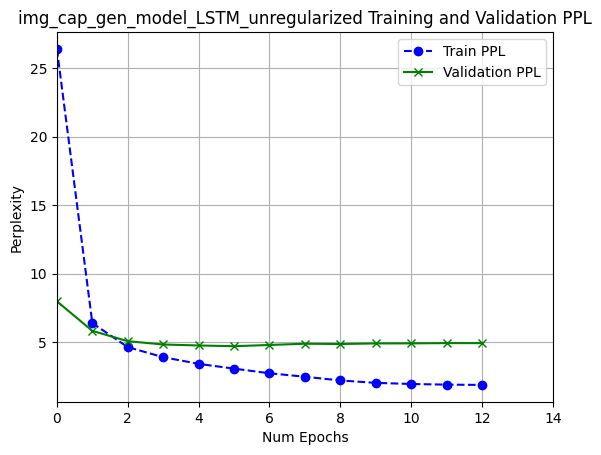

In [25]:
plot_train_valid(metrics_unregularized_DICT,save_plot=True,show_plot=True)

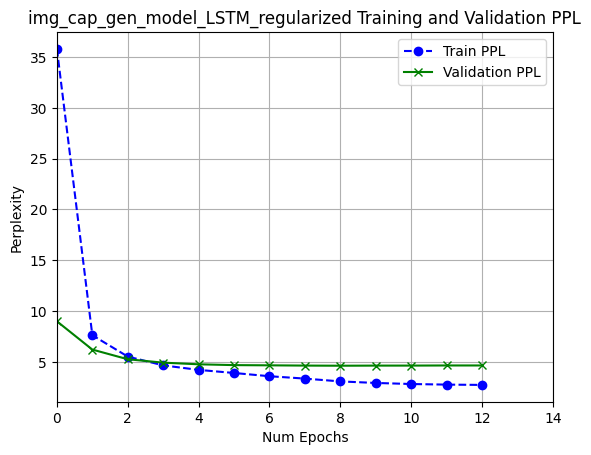

In [26]:
plot_train_valid(metrics_regularized_DICT,save_plot=True,show_plot=True)

# 3. Hyperparameter Tuning Using LSTMs

### 3.1 Variable Initializations

In [ ]:
base_path_ext = "data/"
current_application_ext = "image_text_generation/"
data_type_ext = "output_data/"
model_type_ext = "lstm/"
experiment_type_ext = "hyperparameter_tune/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global input_filepath_ext
global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

input_data_type_ext = "input_data/"
input_filepath_ext = base_path_ext + current_application_ext + input_data_type_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [ ]:
set_of_hyperparams = {
    "model_name": "img_cap_gen_model_LSTM_tune",
    "save_interval_list": [10],
    "batch_size_list": [128],
    "seq_length_list": [32],
    "num_layers_list": [1], 
    "decay_list": [1.2],
    "layer_size_list": [128,256,512],
    "dropout_list": [0.0,0.25,0.5],
    "init_weight_list": [0.08],
    "lr_list": [0.5,0.25],
    "vocab_DICT_size_list": [10000],
    "max_epoch_list": [4],
    "max_max_epoch_list": [30],
    "max_grad_norm_list": [5],
    "beam_search": [True],
    "beam_width": [12,20]
}

### 3.2 Perform An Experiment

In [ ]:
#Performs a single experiment using the specified parameters
def single_experiment(params,save_plot=True,show_plot=True,is_hyperparameter_tune=False,model_class="LSTMModel"):
    print("------------------------------------------------------------------------------")
    print(f"Running experiment with parameters: {params}")
    start_time = time.time()    
    save_images = False #Change to True to save images
    data_train,data_valid,data_test,vocab_DICT_map = get_datasets(params,save_images=save_images)

    train_dataset = Flickr8kDataset(data_train,vocab_DICT_map,input_filepath_ext,params["seq_length"])
    valid_dataset = Flickr8kDataset(data_valid,vocab_DICT_map,input_filepath_ext,params["seq_length"])
    test_dataset = Flickr8kDataset(data_test,vocab_DICT_map,input_filepath_ext,params["seq_length"])

    train_loader = DataLoader(train_dataset,batch_size=params["batch_size"],shuffle=True,collate_fn=collate_fn)
    valid_loader = DataLoader(valid_dataset,batch_size=params["batch_size"],shuffle=False,collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset,batch_size=params["batch_size"],shuffle=False,collate_fn=collate_fn)

    last_epoch = False #Change this to False to train from scratch
    epoch_num = 0 #Change this to load at a specific epoch
    criterion = torch.nn.CrossEntropyLoss() 

    model,model_path,metrics_DICT = check_and_load_model(params,epoch_num,last_epoch=last_epoch,model_class=model_class)
    encoder = model['encoder']
    decoder = model['decoder']
    optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=params["lr"])
    
    patience = False
    model,metrics_DICT = train(train_loader,valid_loader,model,metrics_DICT,params,optimizer,criterion,vocab_DICT_map,model_class=model_class)

    model,_,metrics_DICT = check_and_load_model(params,metrics_DICT["best_epoch"],best_model=True,model_class=model_class)
    test_ppl,test_bleu,metrics_DICT = evaluate(test_loader,model['encoder'],model['decoder'],metrics_DICT,params,criterion,vocab_DICT_map,model_class=model_class)
        
    plot_train_valid(metrics_DICT,save_plot=save_plot,show_plot=show_plot,is_hyperparameter_tune=is_hyperparameter_tune)
    print(f"Experiment completed in {time.time() - start_time:.2f} seconds")
    print()
    return metrics_DICT,model_path

### 3.3 Perform All Experiments

In [ ]:
#Performs all experiements using every specified combination of parameters
def perform_all_experiments(set_of_hyperparams,load_all_results=True,save_plot=True,show_plot=False,model_class="LSTMModel"):
    base_model_name = set_of_hyperparams["model_name"]
    all_results_path = f"{metrics_filepath_ext}{base_model_name}_all_results.pkl"

    all_results_DICT = load_PKL(all_results_path)

    is_initialized = len(all_results_DICT) > 0

    keys = [k for k in set_of_hyperparams if k.endswith("_list")]
    value_lists = [set_of_hyperparams[k] for k in keys]

    for values in itertools.product(*value_lists):
        current_params = {}
        for key, value in zip(keys, values):
            param_key = key.replace("_list", "")
            current_params[param_key] = value

        model_name = base_model_name
        model_name += "_"
        for key in current_params:
            model_name += f"{key}{current_params[key]}"
            
        model_name = model_name.replace("save_interval","svint")
        model_name = model_name.replace("batch_size","bsiz")
        model_name = model_name.replace("seq_length","sqlen")
        model_name = model_name.replace("num_layers","nlyrs")
        model_name = model_name.replace("decay","dc")
        model_name = model_name.replace("layer_size","lyrsiz")
        model_name = model_name.replace("dropout","drop")
        model_name = model_name.replace("init_weight","iniwt")
        model_name = model_name.replace("lr","lr")
        model_name = model_name.replace("vocab_DICT_size","vcsiz")
        model_name = model_name.replace("max_max_epoch","mxmxepch")
        model_name = model_name.replace("max_epoch","mxepch")
        model_name = model_name.replace("max_grad_norm","mxgrdn")
        model_name = model_name.replace("beam_search","bmsch")
        model_name = model_name.replace("beam_width","bmwd")
                        
        current_params["model_name"] = model_name

        if is_initialized and "list_of_model_name" in all_results_DICT and model_name in all_results_DICT["list_of_model_name"]:
            print(f"Skipping previously completed: {model_name}")
            continue

        result_DICT,model_path = single_experiment(current_params,save_plot=save_plot,show_plot=show_plot,is_hyperparameter_tune=True,model_class=model_class)

        if not is_initialized:
            for key in result_DICT:
                new_key = "list_of_"+key
                all_results_DICT[new_key] = []
            is_initialized = True

        for key, value in result_DICT.items():
            new_key = "list_of_"+key
            all_results_DICT[new_key].append(value)

        save_PKL(all_results_DICT,all_results_path)

    save_PKL(all_results_DICT, all_results_path)
    return all_results_DICT

In [ ]:
all_results_DICT = perform_all_experiments(set_of_hyperparams,load_all_results=True,show_plot=False)

### 3.4 Find Best Experiment

In [ ]:
#Returns the best model based on the validation BLEU score
def get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams):
    best_models_params_and_results_DICT = {
        "best_unregularized_model": {},
        "best_regularized_model": {}
    }
    
    best_index_unregularized = None
    best_valid_bleu_unregularized = -np.inf
    
    best_index_regularized = None
    best_valid_bleu_regularized = -np.inf

    base_model_name = set_of_hyperparams["model_name"]
    best_model_params_summary_path = f"{metrics_filepath_ext}{base_model_name}_best_hyperparameters_summary.pkl"

    for i in range(len(all_results_DICT["list_of_model_name"])):
        valid_ppl = all_results_DICT["list_of_best_valid_ppl"][i]
        valid_bleu = all_results_DICT["list_of_best_valid_bleu"][i]
        dropout = all_results_DICT["list_of_dropout"][i]
        model_name = all_results_DICT["list_of_model_name"][i]
        
        is_regularized = dropout > 0.0
        model_type = "best_regularized_model" if is_regularized else "best_unregularized_model"

        print(f"[{model_type}] Model: {model_name} | Val PPL: {valid_ppl:.4f}")
        #print(f"[{model_type}] Model: {model_name} | Val PPL: {valid_ppl:.4f} | Val BLEU: {valid_bleu:.4f}")

        if not is_regularized and valid_bleu > best_valid_bleu_unregularized:
            best_index_unregularized = i
            best_valid_bleu_unregularized = valid_bleu
        elif is_regularized and valid_bleu > best_valid_bleu_regularized:
            best_index_regularized = i
            best_valid_bleu_regularized = valid_bleu

    for model_type in ["best_unregularized_model", "best_regularized_model"]:
        for key in all_results_DICT:
            if model_type == "best_unregularized_model":
                best_models_params_and_results_DICT[model_type][key.replace("list_of_","")] = all_results_DICT[key][best_index_unregularized]
            else:
                best_models_params_and_results_DICT[model_type][key.replace("list_of_","")] = all_results_DICT[key][best_index_regularized]
    
        curr_best_model_params_and_results_DICT = best_models_params_and_results_DICT[model_type]
        print("------------------------------------------------------------------------------")
        if curr_best_model_params_and_results_DICT:
            print(f"Best {model_type} model based on validation PPL:")
            for key in curr_best_model_params_and_results_DICT:
                if not key.endswith("_list"):
                    print(f"{key}: {curr_best_model_params_and_results_DICT[key]}")
        else:
            print(f"No {model_type} model found.")
        print()

    save_PKL(best_models_params_and_results_DICT,best_model_params_summary_path)
    return best_models_params_and_results_DICT

In [ ]:
best_models_params_and_results_DICT = get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams)

### 3.5 Plot Best Experiment Metrics

In [ ]:
plot_train_valid(best_models_params_and_results_DICT['best_unregularized_model'],save_plot=True,show_plot=True)

In [ ]:
plot_train_valid(best_models_params_and_results_DICT['best_regularized_model'],save_plot=True,show_plot=True)

# 4. Original Experiment Using GRUs

### 4.1 Variable Initializations

In [ ]:
base_path_ext = "data/"
current_application_ext = "image_text_generation/"
data_type_ext = "output_data/"
model_type_ext = "gru/"
experiment_type_ext = "original/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global input_filepath_ext
global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

input_data_type_ext = "input_data/"
input_filepath_ext = base_path_ext + current_application_ext + input_data_type_ext 

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [ ]:
#Set unregularized parameters
params_unregularized = {
    "model_name": "img_cap_gen_model_GRU_unregularized",
    "save_interval": 10,
    "batch_size": 128,
    "seq_length": 32,
    "num_layers": 1,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.0,
    "init_weight": 0.1,
    "lr": 0.01,
    "vocab_DICT_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

In [ ]:
#Set regularized parameters
params_regularized = {
    "model_name": "img_cap_gen_model_GRU_regularized",
    "save_interval": 10,
    "batch_size": 128,
    "seq_length": 32,
    "num_layers": 1,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.5,
    "init_weight": 0.1,
    "lr": 0.01,
    "vocab_DICT_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

### 4.2 GRU Cell Class

In [ ]:
class GRUCell(nn.Module):
    #Initialize the GRU cell with weights for each gate
    def __init__(self,input_size,hidden_size):
        super(GRUCell,self).__init__()
        self.hidden_size = hidden_size

        self.W_z = nn.Linear(input_size,hidden_size)
        self.U_z = nn.Linear(hidden_size,hidden_size)

        self.W_r = nn.Linear(input_size,hidden_size)
        self.U_r = nn.Linear(hidden_size,hidden_size)

        self.W_h = nn.Linear(input_size,hidden_size)
        self.U_h = nn.Linear(hidden_size,hidden_size)

    #Compute the next hidden state using the state equations
    def forward(self,x,prev_h):
        z = torch.sigmoid(self.W_z(x) + self.U_z(prev_h))
        r = torch.sigmoid(self.W_r(x) + self.U_r(prev_h))
        h_tilde = torch.tanh(self.W_h(x) + r*self.U_h(prev_h))
        next_h = (1 - z)*h_tilde + z*prev_h
        return next_h

### 4.3 GRU Decoder Class

In [ ]:
class GRUDecoder(nn.Module):
    #Initialize the GRU Decoder
    def __init__(self,params):
        super(GRUDecoder, self).__init__()
        
        self.vocab_DICT_size = params["vocab_DICT_size"]
        self.layer_size = params["layer_size"]
        self.embedding = nn.Embedding(self.vocab_DICT_size, self.layer_size)
        
        self.gru_cells = nn.ModuleList([
            GRUCell(self.layer_size,self.layer_size) for _ in range(params["num_layers"])
        ])
        
        self.init_h = nn.Linear(self.layer_size,self.layer_size)

        self.dropout = nn.Dropout(params["dropout"])
        self.fc = nn.Linear(self.layer_size, self.vocab_DICT_size)
        
        self.init_weights(params)

    #Initialize weights uniformly
    def init_weights(self,params):
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"],params["init_weight"])

        for name, param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)

    #Initialize hidden layers
    def init_hidden(self, image_features):
        h = [self.init_h(image_features) for _ in range(len(self.gru_cells))]
        return h

    #Propagate input through the model
    def forward(self, input_token, hidden):
        embedded = self.embedding(input_token)
        x = embedded
        h = hidden

        for i, cell in enumerate(self.gru_cells):
            prev_h = h[i]
            next_h = cell(x, prev_h)
            x = self.dropout(next_h)
            h[i] = next_h

        output = self.fc(x)
        return output,h

### 4.4 Model Initialization

In [ ]:
last_epoch_unregularized = False #Change this to False to train from scratch
epoch_num_unregularized = 0 #Change this to load at a specific epoch
criterion = torch.nn.CrossEntropyLoss() 

model_unregularized,model_path_unregularized,metrics_unregularized_DICT = check_and_load_model(params_unregularized,epoch_num_unregularized,last_epoch=last_epoch_unregularized,model_class="GRUModel")
encoder_unregularized = model_unregularized['encoder']
decoder_unregularized = model_unregularized['decoder']
optimizer_unregularized = optim.Adam(list(encoder_unregularized.parameters()) + list(decoder_unregularized.parameters()), lr=params_unregularized["lr"])

In [ ]:
last_epoch_regularized = False #Change this to False to train from scratch
epoch_num_regularized = 0 #Change this to load at a specific epoch

model_regularized,model_path_regularized,metrics_regularized_DICT = check_and_load_model(params_regularized,epoch_num_regularized,last_epoch=last_epoch_regularized,model_class="GRUModel")
encoder_regularized = model_regularized['encoder']
decoder_regularized = model_regularized['decoder']
optimizer_regularized = optim.Adam(list(encoder_regularized.parameters()) + list(decoder_regularized.parameters()), lr=params_regularized["lr"])

### 4.5. Train and Evaluate Model

In [ ]:
patience_unregularized = False #Set to 0, None, or False to disable early stopping
model_unregularized,metrics_unregularized_DICT = train(train_loader_unregularized,valid_loader_unregularized,model_unregularized,metrics_unregularized_DICT,params_unregularized,optimizer_unregularized,criterion,vocab_DICT_map_unregularized,model_class="GRUModel")

model_unregularized,_,metrics_unregularized_DICT = check_and_load_model(params_unregularized,metrics_unregularized_DICT["best_epoch"],best_model=True,model_class="GRUModel")
test_ppl,test_bleu,metrics_unregularized_DICT = evaluate(test_loader_unregularized,model_unregularized['encoder'],model_unregularized['decoder'],metrics_unregularized_DICT,params_unregularized,criterion,vocab_DICT_map_unregularized,model_class="GRUModel")

  8%|▊         | 1/13 [08:16<1:39:19, 496.64s/it]

Epoch 1/13, Train PPL: 18.5813, Val PPL: 7.4446


 15%|█▌        | 2/13 [16:27<1:30:25, 493.24s/it]

Epoch 2/13, Train PPL: 5.4715, Val PPL: 5.5941


 23%|██▎       | 3/13 [24:39<1:22:05, 492.51s/it]

...

Epoch 11/13, Train PPL: 1.3655, Val PPL: 6.2702


 92%|█████████▏| 12/13 [1:38:03<08:09, 489.16s/it]

Epoch 12/13, Train PPL: 1.3366, Val PPL: 6.3389
Epoch 13/13, Train PPL: 1.3208, Val PPL: 6.3267


100%|██████████| 13/13 [1:46:17<00:00, 490.59s/it]


Test PPL: 4.8721


In [ ]:
patience_regularized = False #Set to 0, None, or False to disable early stopping
model_regularized,metrics_regularized_DICT = train(train_loader_regularized,valid_loader_regularized,model_regularized,metrics_regularized_DICT,params_regularized,optimizer_regularized,criterion,vocab_DICT_map_regularized,model_class="GRUModel")

model_regularized,_,metrics_regularized_DICT = check_and_load_model(params_regularized,metrics_regularized_DICT["best_epoch"],best_model=True,model_class="GRUModel")
test_ppl,test_bleu,metrics_regularized_DICT = evaluate(test_loader_regularized,model_regularized['encoder'],model_regularized['decoder'],metrics_unregularized_DICT,params_regularized,criterion,vocab_DICT_map_regularized,model_class="GRUModel")

  8%|▊         | 1/13 [08:26<1:41:13, 506.10s/it]

Epoch 1/13, Train PPL: 18.7780, Val PPL: 6.5595


 15%|█▌        | 2/13 [16:40<1:31:29, 499.02s/it]

Epoch 2/13, Train PPL: 5.6078, Val PPL: 5.1757


 23%|██▎       | 3/13 [24:54<1:22:48, 496.83s/it]

...

Epoch 11/13, Train PPL: 1.8942, Val PPL: 4.8497


 92%|█████████▏| 12/13 [2:14:51<13:30, 810.18s/it]

Epoch 12/13, Train PPL: 1.8596, Val PPL: 4.8356
Epoch 13/13, Train PPL: 1.8391, Val PPL: 4.8278


100%|██████████| 13/13 [2:29:55<00:00, 691.97s/it]


Test PPL: 4.4242


### 4.6. Plotting Results

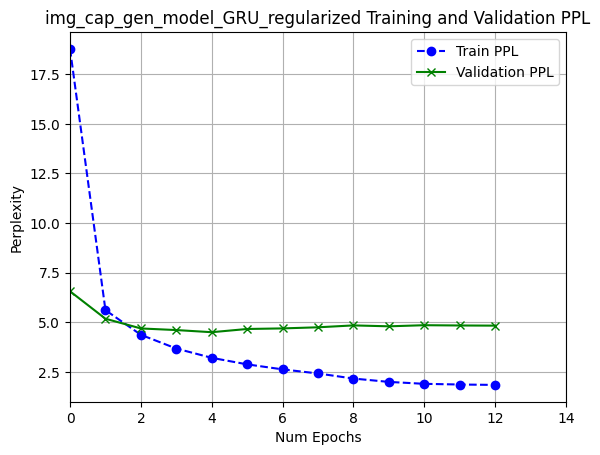

In [47]:
plot_train_valid(metrics_unregularized_DICT,save_plot=True,show_plot=True)

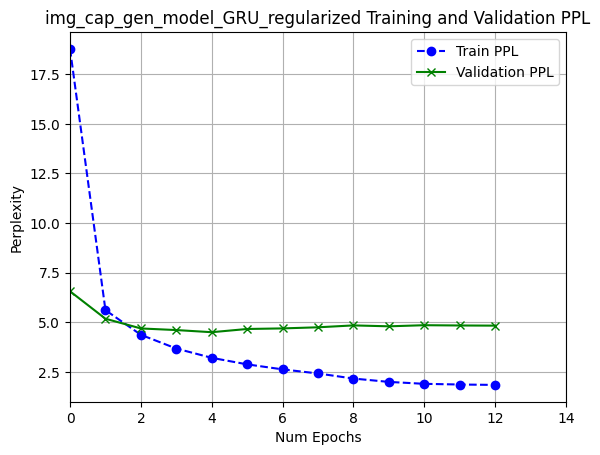

In [48]:
plot_train_valid(metrics_regularized_DICT,save_plot=True,show_plot=True)

# 5. Hyperparameter Tuning Using GRUs

### 5.1 Variable Initializations

In [ ]:
base_path_ext = "data/"
current_application_ext = "image_text_generation/"
data_type_ext = "output_data/"
model_type_ext = "gru/"
experiment_type_ext = "hyperparameter_tune/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global input_data_filepath_ext
global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

input_data_type_ext = "input_data/"
input_filepath_ext = base_path_ext + current_application_ext + input_data_type_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [ ]:
set_of_hyperparams = {
    "model_name": "img_cap_gen_model_GRU_tune",
    "save_interval_list": [10],
    "batch_size_list": [128],
    "seq_length_list": [32],
    "num_layers_list": [1], 
    "decay_list": [1.2],
    "layer_size_list": [128,256,512],
    "dropout_list": [0.0,0.25,0.5],
    "init_weight_list": [0.08],
    "lr_list": [0.5,0.25],
    "vocab_DICT_size_list": [10000],
    "max_epoch_list": [4],
    "max_max_epoch_list": [30],
    "max_grad_norm_list": [5],
    "beam_search": [True],
    "beam_width": [12,20]
}

### 5.2 Perform All Experiments

In [ ]:
all_results_DICT = perform_all_experiments(set_of_hyperparams,load_all_results=True,show_plot=False,model_class="GRUModel")

### 5.3 Find Best Experiment

In [ ]:
best_models_params_and_results_DICT = get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams)

### 5.4 Plot Best Experiment Metrics

In [ ]:
plot_train_valid(best_models_params_and_results_DICT['best_unregularized_model'],save_plot=True,show_plot=True)

In [ ]:
plot_train_valid(best_models_params_and_results_DICT['best_regularized_model'],save_plot=True,show_plot=True)